# Laptop Price Prediction

This project aims to build a machine learning model that predicts the price of a laptop based on its specifications.

The project follows an end-to-end machine learning pipeline including data cleaning, exploratory data analysis, feature engineering, model training, evaluation, and deployment.

## 2. Objective

The objective of this project is to develop a machine learning model that can predict laptop prices based on features such as brand, processor, RAM, storage, GPU, display specifications, and other laptop characteristics.

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
df = pd.read_csv("../data/computer_prices_all.csv")

In [135]:
df.head()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [136]:
df.tail()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
99995,Laptop,ASUS,ASUS Pro ZWL,2023,Windows,Mainstream,Intel,Intel i7-13721,4,12,...,1920x1080,144,90,180,0,Wi-Fi 6,5.1,1.87,24,1712.99
99996,Laptop,Lenovo,Lenovo Stealth 014,2018,Windows,Ultrabook,AMD,AMD Ryzen 5 5117,2,8,...,2560x1600,90,50,65,0,Wi-Fi 6,5.1,1.37,12,1258.99
99997,Laptop,ASUS,ASUS Zen LKD,2020,Windows,Mainstream,Intel,Intel i5-12677,2,6,...,2560x1600,120,99,180,0,Wi-Fi 6,4.2,1.17,12,1686.99
99998,Laptop,ASUS,ASUS Blade DH6,2020,Windows,Mainstream,AMD,AMD Ryzen 7 4590,4,12,...,2560x1600,120,60,90,0,Wi-Fi 6,5.3,1.70,24,2164.99
99999,Desktop,Acer,Acer Think L7R,2023,Windows,SFF,Intel,Intel i9-14345,6,26,...,1920x1080,144,0,0,750,Wi-Fi 6E,5.1,7.00,48,3005.99


In [137]:
df.shape

(100000, 33)

In [138]:
df.columns

Index(['device_type', 'brand', 'model', 'release_year', 'os', 'form_factor',
       'cpu_brand', 'cpu_model', 'cpu_tier', 'cpu_cores', 'cpu_threads',
       'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_brand', 'gpu_model', 'gpu_tier',
       'vram_gb', 'ram_gb', 'storage_type', 'storage_gb',
       'storage_drive_count', 'display_type', 'display_size_in', 'resolution',
       'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'wifi',
       'bluetooth', 'weight_kg', 'warranty_months', 'price'],
      dtype='str')

In [139]:
df.dtypes

device_type                str
brand                      str
model                      str
release_year             int64
os                         str
form_factor                str
cpu_brand                  str
cpu_model                  str
cpu_tier                 int64
cpu_cores                int64
cpu_threads              int64
cpu_base_ghz           float64
cpu_boost_ghz          float64
gpu_brand                  str
gpu_model                  str
gpu_tier                 int64
vram_gb                  int64
ram_gb                   int64
storage_type               str
storage_gb               int64
storage_drive_count      int64
display_type               str
display_size_in        float64
resolution                 str
refresh_hz               int64
battery_wh               int64
charger_watts            int64
psu_watts                int64
wifi                       str
bluetooth              float64
weight_kg              float64
warranty_months          int64
price   

In [140]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  str    
 1   brand                100000 non-null  str    
 2   model                100000 non-null  str    
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  str    
 5   form_factor          100000 non-null  str    
 6   cpu_brand            100000 non-null  str    
 7   cpu_model            100000 non-null  str    
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  cpu_base_ghz         100000 non-null  float64
 12  cpu_boost_ghz        100000 non-null  float64
 13  gpu_brand            100000 non-null  str    
 14  gpu_model            100000 non-null  str    
 15  gpu_tier             100000 n

In [141]:
df.nunique()

device_type                2
brand                     10
model                  99036
release_year               8
os                         4
form_factor               10
cpu_brand                  3
cpu_model              26971
cpu_tier                   6
cpu_cores                 12
cpu_threads               25
cpu_base_ghz               8
cpu_boost_ghz             18
gpu_brand                  4
gpu_model                 49
gpu_tier                   6
vram_gb                    8
ram_gb                    15
storage_type               4
storage_gb                 5
storage_drive_count        4
display_type               6
display_size_in            9
resolution                 6
refresh_hz                 6
battery_wh                 8
charger_watts              7
psu_watts                  9
wifi                       4
bluetooth                  5
weight_kg                 47
warranty_months            4
price                   3366
dtype: int64

In [142]:
df.describe()

,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.591322,3.531310,2.991350,6.152180,39.706400,903.936000,1.524980,20.126655,98.464860,41.813470,61.383450,272.520500,5.084764,4.289699,22.20036,1928.764220
std,2.025761,1.373175,5.044092,9.718426,0.336435,0.350024,1.459643,3.964926,31.902684,774.243654,0.797284,6.709577,43.301652,35.868841,62.795034,354.686355,0.245977,3.814628,10.23190,580.492689
min,2018.000000,1.000000,4.000000,4.000000,2.000000,2.800000,1.000000,0.000000,8.000000,256.000000,1.000000,13.300000,60.000000,0.000000,0.000000,0.000000,4.200000,0.920000,12.00000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.400000,3.300000,2.000000,4.000000,16.000000,512.000000,1.000000,14.000000,60.000000,0.000000,0.000000,0.000000,5.000000,1.500000,12.00000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,2.600000,3.500000,3.000000,6.000000,32.000000,512.000000,1.000000,16.000000,90.000000,56.000000,65.000000,0.000000,5.100000,2.000000,24.00000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,2.800000,3.800000,4.000000,8.000000,64.000000,1024.000000,2.000000,27.000000,120.000000,70.000000,90.000000,650.000000,5.200000,7.000000,24.00000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,3.400000,4.500000,6.000000,16.000000,144.000000,4096.000000,4.000000,34.000000,240.000000,99.000000,240.000000,1200.000000,5.300000,16.000000,48.00000,10984.990000


In [143]:
df.describe(include="object")

/var/folders/h3/lh053x3x2tz06h7f0x583b380000gn/T/ipykernel_28721/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,device_type,brand,model,os,form_factor,cpu_brand,cpu_model,gpu_brand,gpu_model,storage_type,display_type,resolution,wifi
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,2,10,99036,4,10,3,26971,4,49,4,6,6,4
top,Laptop,Lenovo,ASUS Slim R6S,Windows,Mainstream,Intel,Apple M2 Pro,NVIDIA,Apple Integrated,NVMe,LED,1920x1080,Wi-Fi 6
freq,59844,15992,3,71817,17819,52774,1389,54712,18922,45059,32000,47993,46149


In [144]:
df["device_type"].value_counts()

device_type
Laptop     59844
Desktop    40156
Name: count, dtype: int64

In [145]:
df = df[df["device_type"] == "Laptop"].copy()

In [146]:
df.shape

(59844, 33)

In [147]:
df.isnull().sum()

device_type            0
brand                  0
model                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_model              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
cpu_base_ghz           0
cpu_boost_ghz          0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
display_size_in        0
resolution             0
refresh_hz             0
battery_wh             0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64

In [148]:
df.duplicated().sum()

np.int64(0)

In [149]:
df.columns.tolist()

['device_type',
 'brand',
 'model',
 'release_year',
 'os',
 'form_factor',
 'cpu_brand',
 'cpu_model',
 'cpu_tier',
 'cpu_cores',
 'cpu_threads',
 'cpu_base_ghz',
 'cpu_boost_ghz',
 'gpu_brand',
 'gpu_model',
 'gpu_tier',
 'vram_gb',
 'ram_gb',
 'storage_type',
 'storage_gb',
 'storage_drive_count',
 'display_type',
 'display_size_in',
 'resolution',
 'refresh_hz',
 'battery_wh',
 'charger_watts',
 'psu_watts',
 'wifi',
 'bluetooth',
 'weight_kg',
 'warranty_months',
 'price']

In [150]:
df["price"].describe()

count    59844.000000
mean      2002.051360
std        599.506201
min        372.990000
25%       1556.990000
50%       1934.990000
75%       2378.990000
max      10984.990000
Name: price, dtype: float64

In [151]:
df["brand"].value_counts()

brand
Lenovo      9507
Dell        8371
HP          8362
Apple       7130
ASUS        6093
Acer        6044
Samsung     4948
MSI         4673
Gigabyte    2875
Razer       1841
Name: count, dtype: int64

In [152]:
df["cpu_brand"].value_counts()

cpu_brand
Intel    31643
AMD      21071
Apple     7130
Name: count, dtype: int64

In [153]:
df["gpu_brand"].value_counts()

gpu_brand
NVIDIA    32745
Apple     11393
AMD        9359
Intel      6347
Name: count, dtype: int64

In [154]:
df["os"].value_counts()

os
Windows     42935
macOS       11002
Linux        3613
ChromeOS     2294
Name: count, dtype: int64

In [155]:
df["price"].describe()

count    59844.000000
mean      2002.051360
std        599.506201
min        372.990000
25%       1556.990000
50%       1934.990000
75%       2378.990000
max      10984.990000
Name: price, dtype: float64

In [156]:
df["price"].head(20)

1     2274.99
4     2681.99
8     2953.99
9     1653.99
10    1371.99
14    2045.99
15    2109.99
16    2678.99
17    3421.99
21    2560.99
25    3002.99
26    3546.99
27    2386.99
28    3173.99
32    2269.99
33    1274.99
34    3163.99
35    2232.99
36    2307.99
37    1947.99
Name: price, dtype: float64

In [157]:
df["device_type"].value_counts()

device_type
Laptop    59844
Name: count, dtype: int64

In [158]:
df[["brand", "model", "price"]].head(20)          #(Prices are shown in USD)

,brand,model,price
1,Samsung,Samsung Pro KM8,2274.99
4,Gigabyte,Gigabyte Pro IX1,2681.99
8,Dell,Dell Creator GIQ,2953.99
9,Lenovo,Lenovo Blade MIZ,1653.99
10,HP,HP Pro 6XS,1371.99
14,Lenovo,Lenovo Legion SZI,2045.99
15,Dell,Dell Nitro 614,2109.99
16,Acer,Acer Zen NYU,2678.99
17,Apple,Apple Blade 0BN,3421.99
21,Dell,Dell Slim NHG,2560.99


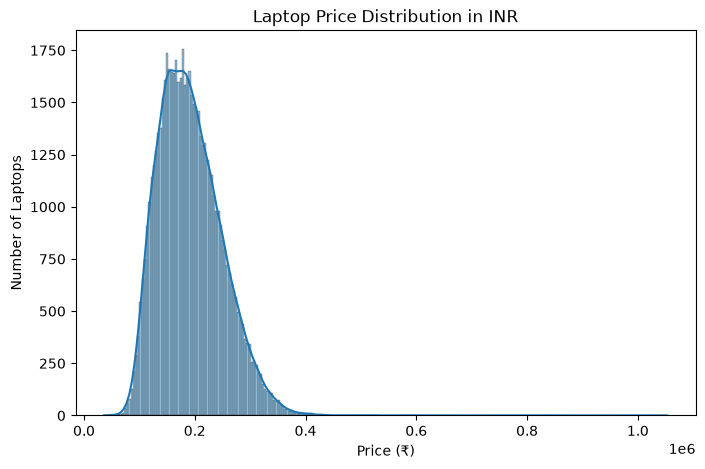

In [159]:
df["price"] = df["price"] * 95.9            #(Prices in INR)

plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)

plt.title("Laptop Price Distribution in INR")
plt.xlabel("Price (₹)")
plt.ylabel("Number of Laptops")
plt.show()

Prices are converted from USD to INR and then illustrated.

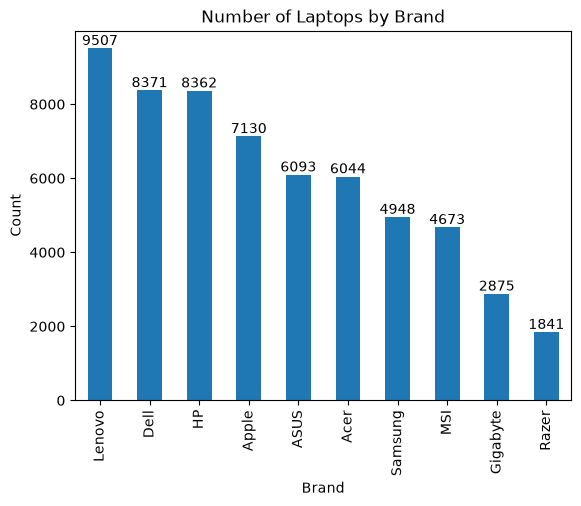

In [160]:
ax=df['brand'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title("Number of Laptops by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

The above graph shows that Lenovo is the most represented brand in the dataset, while Razer has the lowest number of laptops. Overall, the dataset is dominated by Lenovo, Dell, and HP laptops.

/var/folders/h3/lh053x3x2tz06h7f0x583b380000gn/T/ipykernel_28721/1820228749.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=df['brand'],y=df['price'],palette="husl")         #Price in INR


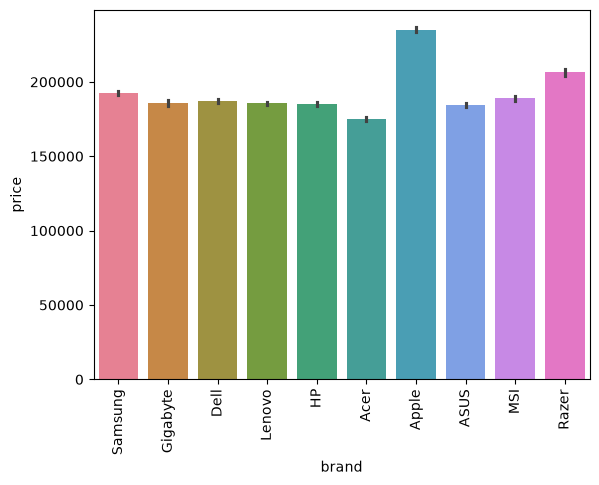

In [161]:
ax=sns.barplot(x=df['brand'],y=df['price'],palette="husl")         #Price in INR
plt.xticks(rotation='vertical')
plt.show()


Apple laptops have the highest average price, whereas Acer laptops have the lowest. The remaining brands show relatively similar average prices, indicating moderate variation in average laptop prices across brands.

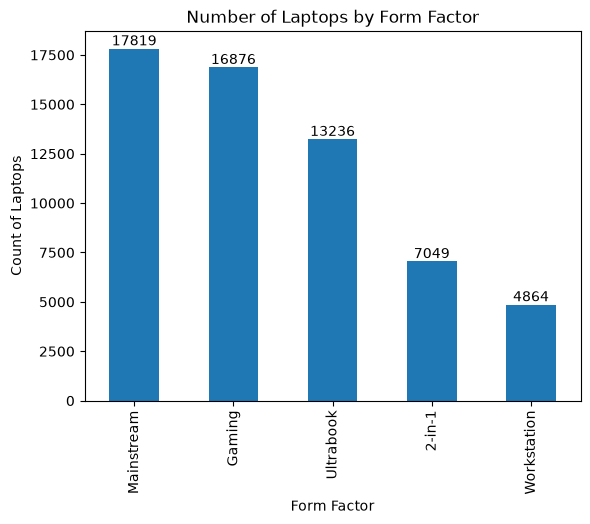

In [162]:
ax=df['form_factor'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title("Number of Laptops by Form Factor")
plt.xlabel("Form Factor")
plt.ylabel("Count of Laptops")
plt.show()

Mainstream and gaming laptops dominate the dataset, while workstations are the least represented form factor. Overall, the dataset contains a higher number of mainstream and performance-oriented laptops.

/var/folders/h3/lh053x3x2tz06h7f0x583b380000gn/T/ipykernel_28721/984422288.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['form_factor'],y=df['price'],palette="viridis")      #Price in INR


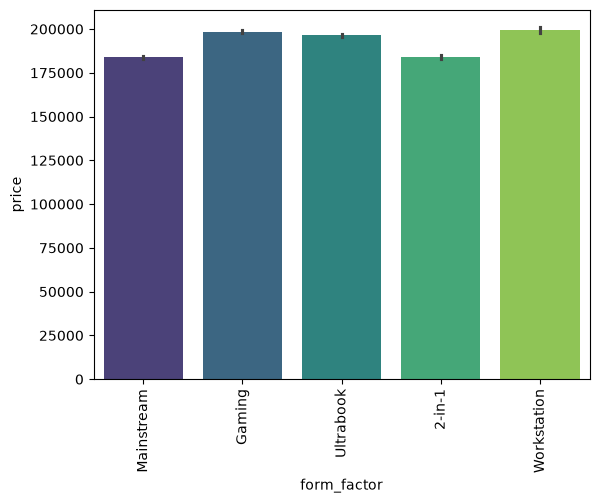

In [163]:
sns.barplot(x=df['form_factor'],y=df['price'],palette="viridis")      #Price in INR
plt.xticks(rotation='vertical')
plt.show()



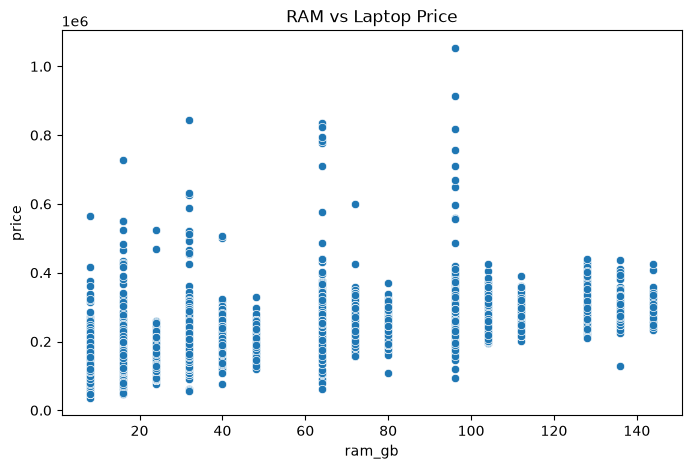

In [164]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="ram_gb", y="price")
plt.title("RAM vs Laptop Price")
plt.show()

The scatter plot shows a few unusually high laptop prices compared with the majority of observations. These points may be potential outliers and should be investigated before model training.

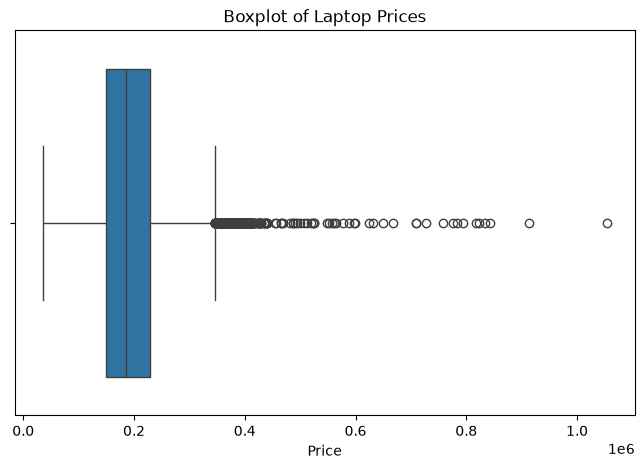

In [165]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Laptop Prices")
plt.xlabel("Price")
plt.show()

In [166]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["price"] = df["price"].clip(lower, upper)

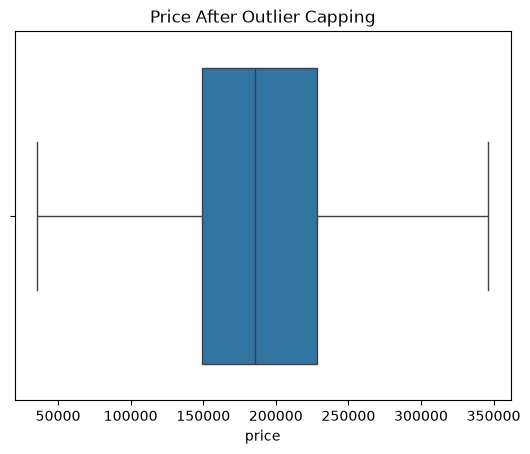

In [167]:
sns.boxplot(x=df["price"])
plt.title("Price After Outlier Capping")
plt.show()

In [168]:
df_original = pd.read_csv("../data/computer_prices_all.csv")

In [169]:
laptop_df = df_original[df_original["device_type"] == "Laptop"].copy()

In [170]:
X = laptop_df.drop(columns=["price"])
y = laptop_df["price"]

In [171]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['device_type', 'brand', 'model', 'release_year', 'os', 'form_factor', 'cpu_brand', 'cpu_model', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_brand', 'gpu_model', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_type', 'storage_gb', 'storage_drive_count', 'display_type', 'display_size_in', 'resolution', 'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'wifi', 'bluetooth', 'weight_kg', 'warranty_months']

Target:
price


In [172]:
X = X.drop(columns=["device_type"], errors="ignore")

In [173]:
print(X.columns.tolist())

['brand', 'model', 'release_year', 'os', 'form_factor', 'cpu_brand', 'cpu_model', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_brand', 'gpu_model', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_type', 'storage_gb', 'storage_drive_count', 'display_type', 'display_size_in', 'resolution', 'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'wifi', 'bluetooth', 'weight_kg', 'warranty_months']


In [174]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [175]:
from sklearn.model_selection import train_test_split

In [176]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [177]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (47875, 31)
Testing data: (11969, 31)


In [178]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()

categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['release_year', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count', 'display_size_in', 'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'bluetooth', 'weight_kg', 'warranty_months']

Categorical features:
['brand', 'model', 'os', 'form_factor', 'cpu_brand', 'cpu_model', 'gpu_brand', 'gpu_model', 'storage_type', 'display_type', 'resolution', 'wifi']


In [179]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [180]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [181]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [182]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [183]:
from sklearn.linear_model import LinearRegression

In [184]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [185]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['brand','model','release_year',...,'bluetooth','weight_kg', 'warranty_months']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subse

In [186]:
y_pred = model.predict(X_test)

In [187]:
print("Actual prices:")
print(y_test.head().values)

print("\nPredicted prices:")
print(y_pred[:5])

Actual prices:
[2690.99 1162.99 1594.99 1647.99 1979.99]

Predicted prices:
[2013.53710919  790.90318271 1495.85641233 2035.15371057 1468.85312007]


In [188]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

##Linear Regression

In [189]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 417.0138255041527
RMSE: 535.0077944402206
R² Score: 0.20681202203605464


##Decision Tree Regression

In [190]:
from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [198]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree
MAE: 220.70724371292505
RMSE: 308.70452647916835
R2 Score: 0.7359161154046754


In [199]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree"
    ],
    "MAE": [
        mae, mae_dt
    ],
    "RMSE": [
        rmse, rmse_dt
    ],
    "R2 Score": [
        r2, r2_dt
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,417.013826,535.007794,0.206812
1,Decision Tree,220.707244,308.704526,0.735916
